# Задание 1

Импортируй `pandas`

In [1]:
import pandas as pd

Загрузи датасет

In [2]:
path = 'https://raw.githubusercontent.com/rhiever/python-data-visualization-course/master/Section%203%20-%20Data%20visualization%20in%20Python%20-%20matplotlib/exercises/data/us-marriages-divorces-1867-2014.csv'
# или 
#path = '../learning/datasets/us-marriages-divorces-1867-2014.csv'
us_marriage_divorce_data = pd.read_csv(path)
us_marriage_divorce_data.head()

,Year,Marriages,Divorces,Population,Marriages_per_1000,Divorces_per_1000
0,1867,357000.0,10000.0,36970000,9.7,0.3
1,1868,345000.0,10000.0,37885000,9.1,0.3
2,1869,348000.0,11000.0,38870000,9.0,0.3
3,1870,352000.0,11000.0,39905000,8.8,0.3
4,1871,359000.0,12000.0,41010000,8.8,0.3


Нарисуйте график, показывающий количество свадеб и разводов на душу населения в США за каждый год от 1867 да 2014.

Подпишите линии и оси, и добавьте легенду.

Сохраните на диск.

**Бонус:** Используйте [стиль](https://matplotlib.org/3.5.1/gallery/style_sheets/style_sheets_reference.html) ggplot.

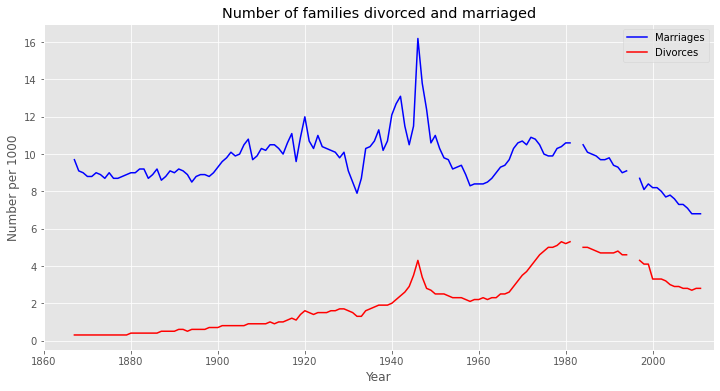

In [227]:
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, MultipleLocator

fig, ax = plt.subplots(figsize=(12, 6))
plt.style.use('ggplot')
ax.plot(us_marriage_divorce_data['Year'], us_marriage_divorce_data['Marriages_per_1000'], label = 'Marriages', color = 'blue')
ax.plot(us_marriage_divorce_data['Year'], us_marriage_divorce_data['Divorces_per_1000'], label = 'Divorces', color = 'red')
ax.set(xlim = (1860, 2014),
        xlabel = 'Year',
        ylabel = 'Number per 1000',
        title = 'Number of families divorced and marriaged')

plt.legend()
plt.show()


# Задание 2

Нарисуйте график, сравнивающий количество свадеб и разводов на душу населения в США между 1900, 1950, и 2000 годами.


No handles with labels found to put in legend.


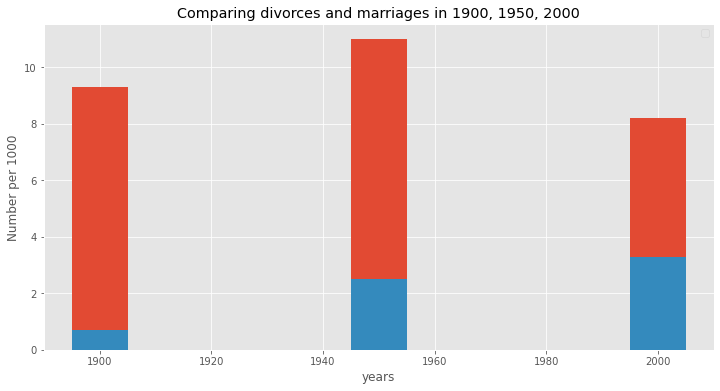

In [290]:
mar_div = us_marriage_divorce_data[['Marriages_per_1000', 'Divorces_per_1000', 'Year']]


fig, ax = plt.subplots(figsize = (12, 6))


years = [1900, 1950, 2000]
mars = mar_div['Marriages_per_1000'][(mar_div['Year']==2000) | (mar_div['Year']==1950) | (mar_div['Year']==1900)].to_numpy()
divs = mar_div['Divorces_per_1000'][(mar_div['Year']==2000) | (mar_div['Year']==1950) | (mar_div['Year']==1900)].to_numpy()

ax.bar(years, mars, width=10)
ax.bar(years, divs, width = 10)

#ax.bar(mar_div['Year'], mar_div['Marriages_per_1000'], width=1, label = 'Marriages')
#ax.bar(mar_div['Year'], mar_div['Divorces_per_1000'], width=1, label = 'Divorces')

ax.set(xlim = (1890, 2010),
        xlabel = 'years',
        ylabel = 'Number per 1000',
        title = 'Comparing divorces and marriages in 1900, 1950, 2000',
)

plt.legend()

plt.show()

# Задание 3
Скачайте датасет `actor_kill_counts.csv` из [папки](https://drive.google.com/drive/u/2/folders/1feIAprMfR-9URRxQAGev02tOhxZo1SH8)

Нарисуйте график, показывающий, сколько киноубийств принадлежит самым "смертоносных" актерам Голливуда.

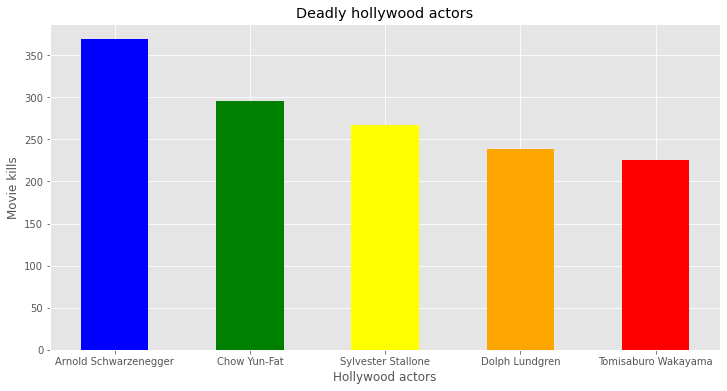

In [311]:
hollywood_actor_kills = pd.read_csv('../../../../datasets/actor_kill_counts.csv')
holly_actor_kills = hollywood_actor_kills.sort_values(by='Count', ascending=False).head()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(holly_actor_kills['Actor'], holly_actor_kills['Count'], width= 0.5, color=['blue', 'green', 'yellow', 'orange', 'red'])
ax.set(
    xlabel = 'Hollywood actors',
    ylabel = 'Movie kills',
    title = 'Deadly hollywood actors'
);

# Задание 4
Скачайте датасет `roman-emperor-reigns.csv` из папки `datasets`

In [315]:
roman_emperors = pd.read_csv('../../../../datasets/roman-emperor-reigns.csv')
roman_emperors.describe

<bound method NDFrame.describe of            Emperor  Length_of_Reign         Cause_of_Death
0         Augustus            40.58  Possibly assassinated
1         Tiberius            22.50  Possibly assassinated
2         Caligula             4.83           Assassinated
3         Claudius            13.75  Possibly assassinated
4             Nero            13.67                Suicide
..             ...              ...                    ...
63   Valentinian I            11.00         Natural causes
64          Valens            14.00       Killed in battle
65         Gratian            16.00           Assassinated
66  Valentinian II            17.00  Possibly assassinated
67    Theodosius I            16.00         Natural causes

[68 rows x 3 columns]>

Нарисуйте график, показывающий количество римских императоров, умерших по каждой из причин. 

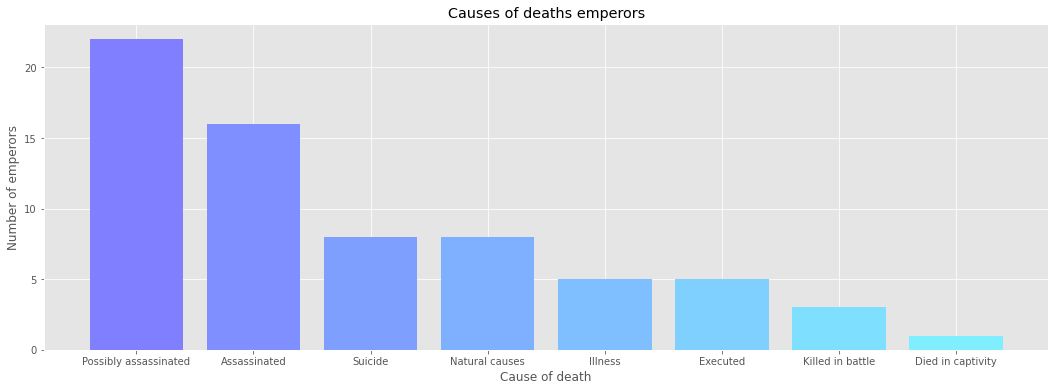

In [349]:
fig, ax = plt.subplots(figsize = (18, 6))

ax.bar(roman_emperors['Cause_of_Death'].unique(), roman_emperors.groupby('Cause_of_Death')['Emperor'].nunique().sort_values(ascending=False),
        color = [(127/255, (127 + i*(255-127)/len(roman_emperors['Cause_of_Death'].unique()))/255, 1)\
             for i in range(0,len(roman_emperors['Cause_of_Death'].unique()))])

ax.set(
    xlabel = 'Cause of death',
    ylabel = 'Number of emperors',
    title = 'Causes of deaths emperors'
);

Нарисуйте график, показывающий зависимость причины смерти и длительности периода правления.

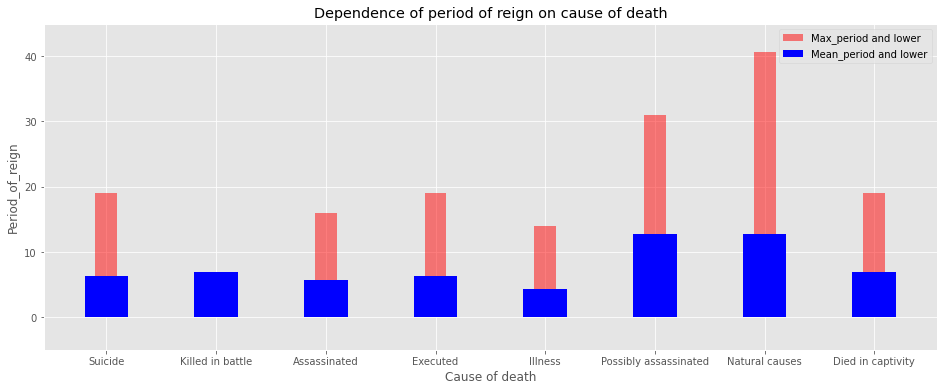

In [492]:
fig, ax = plt.subplots(figsize = (16, 6))

roman_emperors = roman_emperors.sort_values(by = 'Length_of_Reign')

ax.bar(roman_emperors['Cause_of_Death'].unique(), roman_emperors.groupby(by = 'Cause_of_Death')['Length_of_Reign'].max(), 
    width = 0.2, color = 'red', alpha=0.5, label = 'Max_period and lower')
ax.bar(roman_emperors['Cause_of_Death'].unique(), roman_emperors.groupby(by = 'Cause_of_Death')['Length_of_Reign'].mean(),
    width = 0.4, color = 'blue', label = 'Mean_period and lower')

ax.set(ylim = (-5, 45),
    xlabel = 'Cause of death',
    ylabel = 'Period_of_reign',
    title = 'Dependence of period of reign on cause of death')
ax.legend();

# Задание 5

Скачайте датасет `arcade-revenue-vs-cs-doctorates.csv` из [папки](https://drive.google.com/drive/u/2/folders/1feIAprMfR-9URRxQAGev02tOhxZo1SH8)

In [496]:
arcade_revenue_cs_doctorates = pd.read_csv('../../../../datasets/arcade-revenue-vs-cs-doctorates.csv')
arcade_revenue_cs_doctorates

,Year,Total Arcade Revenue (billions),Computer Science Doctorates Awarded (US)
0,2000,1.196,861
1,2001,1.176,830
2,2002,1.269,809
3,2003,1.240,867
4,2004,1.307,948
5,2005,1.435,1129
6,2006,1.601,1453
7,2007,1.654,1656
8,2008,1.803,1787
9,2009,1.734,1611


Нарисуйте график, показывающий связь между доходом залов игровых автоматов и количеством PhD (кандидатов наук) по Computer Science в США с 2000 по 2009 год.